In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

from scipy.stats import boxcox, probplot, norm

from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures

In [10]:
# Load the Yelp business dataset using pandas read_json
# Added lines=True to designate each line to represent a complete JSON object
biz_df = pd.read_json('yelp_academic_dataset_business.json', lines=True)

In [11]:
biz_df.head(3)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [12]:
biz_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB


### Quantization and Binning

Text(0, 0.5, 'Occurence')

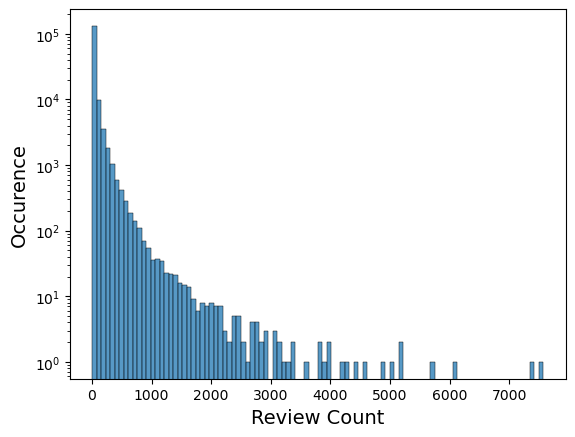

In [20]:
# Creat histogram of the review_count feature
# Set the y axis to be a log scale due to high level of count discrepancies in data
fig, ax = plt.subplots()
sns.histplot(biz_df.review_count, bins=100)
ax.set_yscale('log')
ax.set_xlabel('Review Count', fontsize=14)
ax.set_ylabel('Occurence', fontsize=14)

#### Fixed Width Binning

In [34]:
# Create 20 random numbers between 0 an 99
small_counts = np.random.randint(0,100,20)
print(np.sort(small_counts))

[16 21 27 31 32 41 43 45 46 48 50 55 66 70 74 79 86 93 97 99]


In [38]:
# Take the random numbers generated above and put into 10 evenly spaced bins (0-9)
print(np.floor_divide(np.sort(small_counts), 10))

[1 2 2 3 3 4 4 4 4 4 5 5 6 7 7 7 8 9 9 9]


In [43]:
# Create 18 new integers and place them into log10 bins
large_counts = [296, 8286, 64011, 80, 3, 
                725, 867, 2215, 7689, 11495, 
                91897, 44, 28, 7971, 926, 
                122, 22222]
print(np.floor(np.log10(large_counts)))

[2. 3. 4. 1. 0. 2. 2. 3. 3. 4. 4. 1. 1. 3. 2. 2. 4.]


#### Quantile Binning

In [51]:
# Convert the list to a panda series
# Perform a quantile binning of 0.25, 0.5, and 0.75 percentile buckets
large_count_series = pd.Series(large_counts)
large_count_series.quantile([0.25, 0.5, 0.75])

0.25     122.0
0.50     926.0
0.75    8286.0
dtype: float64

In [58]:
# Create 9 bins based on the number of counts of reviews for a restaurant
deciles = biz_df['review_count'].quantile(np.arange(0.1, 1, 0.1))
deciles

0.1     6.0
0.2     7.0
0.3     9.0
0.4    11.0
0.5    15.0
0.6    20.0
0.7    30.0
0.8    48.0
0.9    97.0
Name: review_count, dtype: float64

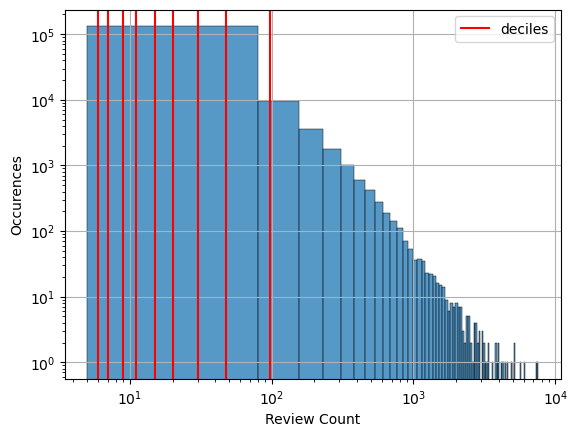

In [77]:
# Create a histgram of the review_counts by 100 bins
# Add Red vertical lines showing the quantile bin placement for 0.1 to 0.9
fig, ax = plt.subplots()
sns.histplot(biz_df['review_count'], bins=100)
for i in deciles:
    handle = plt.axvline(i, color='r')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(['deciles'])
plt.grid(True)
plt.xlabel('Review Count')
plt.ylabel('Occurences')
plt.show()

### Log Transformation

In [78]:
# Create log 10 data points for X based on Y
y = np.arange(0.00001, 3, 0.01)
x = np.power(10,y)

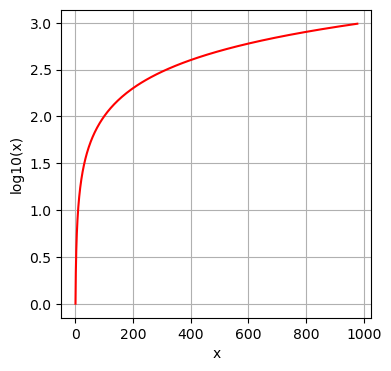

In [89]:
# Graph the data points to show the log dataset
fig, ax = plt.subplots(figsize=(4,4))
plt.plot(x,y,'r')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('log10(x)')
plt.show()

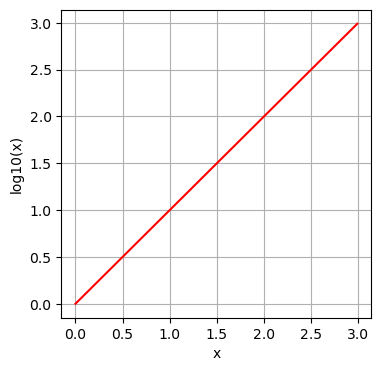

In [90]:
# Transform the X data and replot
# X,Y values should look more linear now
X = np.log10(x)
fig, ax = plt.subplots(figsize=(4,4))
plt.plot(X,y,'r')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('log10(x)')
plt.show()

In [91]:
# Transform the review count to a log10 value
log_review_count = np.log10(biz_df['review_count']+1)

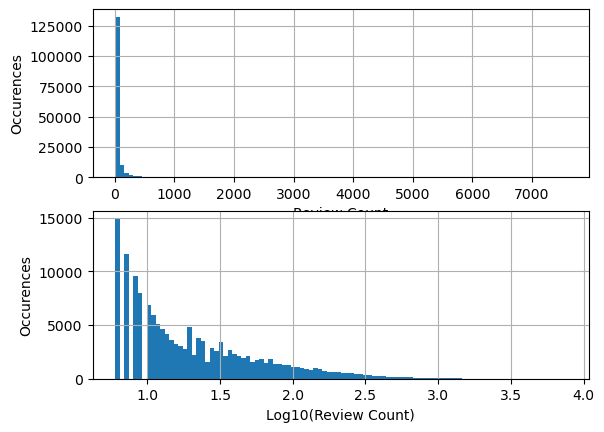

In [101]:
# PLot the original review count values
ax = plt.subplot(2,1,1)
biz_df['review_count'].hist(ax=ax, bins=100)
plt.xlabel('Review Count')
plt.ylabel('Occurences')

# PLot the log10 transformation of the review counts
ax = plt.subplot(2,1,2)
log_review_count.hist(ax=ax, bins=100)
plt.xlabel('Log10(Review Count)')
plt.ylabel('Occurences')
plt.show()

In [106]:
# Return the shape of the biz_df dataset
biz_df.shape

(150346, 15)

In [107]:
# Add a new feature called log_review_count to the biz_df dataset
biz_df['log_review_count'] = np.log10(biz_df['review_count']+1)

In [108]:
biz_df.head(1)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,log_review_count
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None,0.90309


In [178]:
# Create the X original review count X log original review count and Y star array
X_orig = biz_df[['review_count']]
X_log = biz_df[['log_review_count']]
y = biz_df['stars']

In [179]:
# Split the X and Y original data into training and validation
X_train_orig, X_validate_orig, y_train_orig, y_validate_orig = train_test_split(X_orig, y, test_size=0.2)

# Split the X and Y log data into training and validation
X_train_log, X_validate_log, y_train_log, y_validate_log = train_test_split(X_log, y, test_size=0.2)

In [180]:
# Create a linear regrwession model for the original data
m_orig = LinearRegression().fit(X_train_orig, y_train_orig)

# Create a linear regression model for the log transformed data
m_log = LinearRegression().fit(X_train_log, y_train_log)

In [181]:
# Display RSS values
print("Residual sum of squares without log transform: {:.5f}".format(
      np.mean((m_orig.predict(X_validate_orig) - y_validate_orig) ** 2)))

print("Residual sum of squares with log transform: {:.5f}".format(
      np.mean((m_log.predict(X_validate_log) - y_validate_log) ** 2)))

Residual sum of squares without log transform: 0.93656
Residual sum of squares with log transform: 0.96701


In [186]:
# Create R-squared scores for the original data using cross_val_score
m_orig_cv = LinearRegression()
m_orig_cv_score = cross_val_score(m_orig_cv, 
                                  X_train_orig, 
                                  y_train_orig, 
                                  cv=10,
                                  scoring='r2')

In [189]:
# Create R-squared scores for the log transformed data using cross_val_score
m_log_cv = LinearRegression()
m_log_cv_score = cross_val_score(m_log_cv, 
                                 X_train_log, 
                                 y_train_log, 
                                 cv=10,
                                 scoring='r2')

In [190]:
print("R-squared score without log transform: %0.5f (+/- %0.5f)" % (m_orig_cv_score.mean(), m_orig_cv_score.std() * 2))
print("R-squared score with log transform: %0.5f (+/- %0.5f)" % (m_log_cv_score.mean(), m_log_cv_score.std() * 2))

R-squared score without log transform: 0.00334 (+/- 0.00140)
R-squared score with log transform: 0.00252 (+/- 0.00141)


### Online News Data

In [214]:
# Load the online news dartaset
# File contains a ' ,' delimiter
df = pd.read_csv('OnlineNewsPopularity.csv', delimiter=', ', engine='python')
df.head(3)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


In [215]:
# Show the columns of the file
df.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [216]:
# Create a new feature on the log10 of the n_tokens_content feature
df['log_n_tokens_content'] = np.log10(df['n_tokens_content']+1)

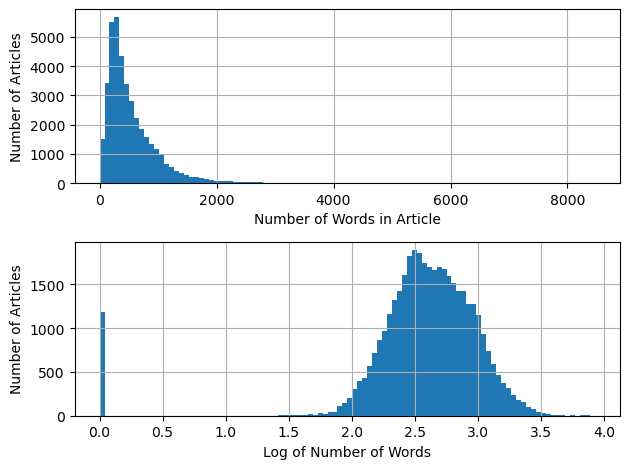

In [237]:
# Plot a histogram of the original n_tokens_content feature that contains the 
# number of words in an article
fig, (ax1, ax2) = plt.subplots(2,1)
df['n_tokens_content'].hist(ax=ax1, bins=100)
ax1.tick_params(labelsize=10)
ax1.set_xlabel('Number of Words in Article', fontsize=10)
ax1.set_ylabel('Number of Articles',fontsize=10)

# PLot a histogram of the log transformed n_tokens_content feature
df['log_n_tokens_content'].hist(ax=ax2, bins=100)
ax2.tick_params(labelsize=10)
ax2.set_xlabel('Log of Number of Words', fontsize=10)
ax2.set_ylabel('Number of Articles', fontsize=10)

plt.tight_layout()
plt.show()

In [238]:
news_orig = LinearRegression()
scores_orig = cross_val_score(news_orig, 
                              df[['n_tokens_content']], 
                              df['shares'], 
                              cv=10, 
                              scoring='r2')

In [239]:
news_log = LinearRegression()
scores_log = cross_val_score(news_log,
                             df[['log_n_tokens_content']],
                             df['shares'],
                             cv=10,
                             scoring='r2')

In [240]:
print(f"R-squared score without log transform: {scores_orig.mean():.5f} (+/-{scores_orig.std()*2:.5f})") 
print(f"R-squared score with log transform: {scores_log.mean():.5f} (+/-{scores_log.std()*2:.5f})") 

R-squared score without log transform: -0.00242 (+/-0.00509)
R-squared score with log transform: -0.00114 (+/-0.00418)


### Visualise the Correlation Between the Input and Output

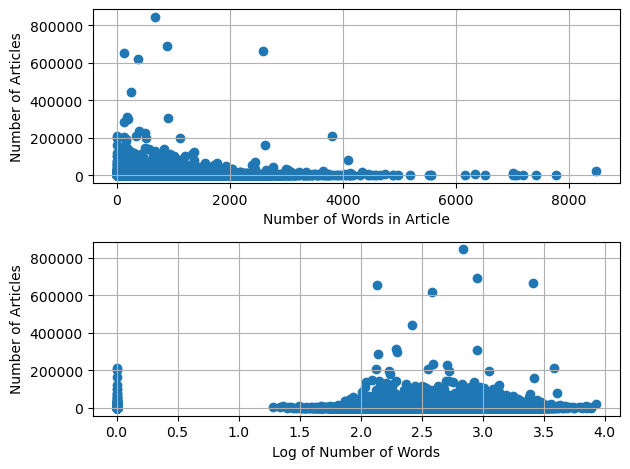

In [246]:
# News Data
fig, (ax1, ax2) = plt.subplots(2,1)
ax1.scatter(df['n_tokens_content'], df['shares'])
ax1.tick_params(labelsize=10)
ax1.set_xlabel('Number of Words in Article', fontsize=10)
ax1.set_ylabel('Number of Articles',fontsize=10)
ax1.grid(True)

ax2.scatter(df['log_n_tokens_content'], df['shares'])
ax2.tick_params(labelsize=10)
ax2.set_xlabel('Log of Number of Words', fontsize=10)
ax2.set_ylabel('Number of Articles', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

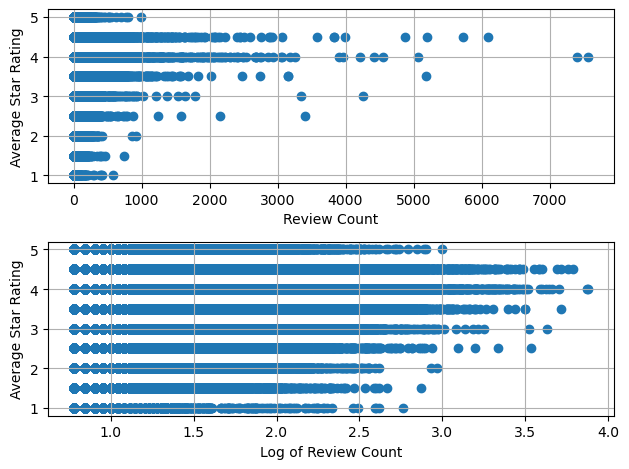

In [247]:
# Yelp Data
fig, (ax1, ax2) = plt.subplots(2,1)
ax1.scatter(biz_df['review_count'], biz_df['stars'])
ax1.tick_params(labelsize=10)
ax1.set_xlabel('Review Count', fontsize=10)
ax1.set_ylabel('Average Star Rating',fontsize=10)
ax1.grid(True)

ax2.scatter(biz_df['log_review_count'], biz_df['stars'])
ax2.tick_params(labelsize=10)
ax2.set_xlabel('Log of Review Count', fontsize=10)
ax2.set_ylabel('Average Star Rating',fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

### Power Transforms: Generalization of the Log Transform

### Box-Cox Example

In [249]:
x = np.arange(0.001, 3, 0.01)
lambda0 = np.log(x)
one_quarter = (x**0.25 - 1)/0.25
square_root = (x**0.5 - 1)/0.5
three_quarters = (x**0.75 - 1)/0.75
one_point_five = (x**1.5 - 1)/1.5

Text(0.5, 1.0, 'Box-Cox Transforms')

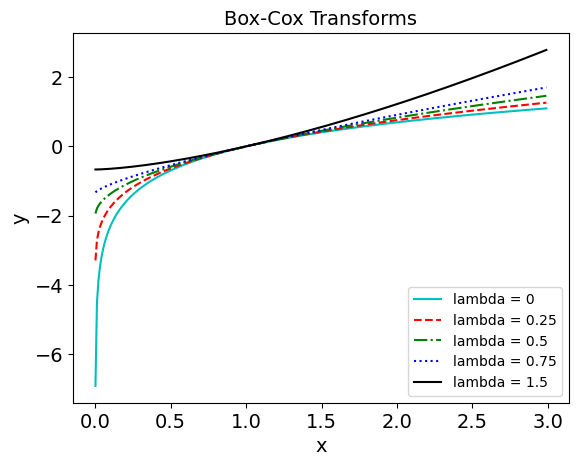

In [251]:
fig, ax = plt.subplots()
plt.plot(x, lambda0, 'c', 
         x, one_quarter, 'r--', 
         x, square_root, 'g-.', 
         x, three_quarters, 'b:',
         x, one_point_five, 'k')
plt.legend(['lambda = 0', 'lambda = 0.25', 'lambda = 0.5', 'lambda = 0.75', 'lambda = 1.5'], 
           loc='lower right')
ax.tick_params(labelsize=14)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_title('Box-Cox Transforms', fontsize=14)

### Box-Cox Transformations of Yelp

In [252]:
biz_df['review_count'].min()

5

In [258]:
rc_log = boxcox(biz_df['review_count'], lmbda=0)

# Determine the lambda parameter that will make the revie_count distribution 
# closer to a normal distribution
rc_bc, bc_params = boxcox(biz_df['review_count'])
bc_params

-0.400108591453397

In [259]:
# Add the rc_bc and rc__log features to the biz_df dataset
biz_df['rc_bc']=rc_bc
biz_df['rc_log']=rc_log

In [261]:
biz_df.head(3)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,log_review_count,rc_bc,rc_log
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None,0.903090,1.351984,1.945910
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ...",1.204120,1.653541,2.708050
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ...",1.361728,1.773705,3.091042


#### Plot the 3 version of review count: original, log transform, box-cox transform

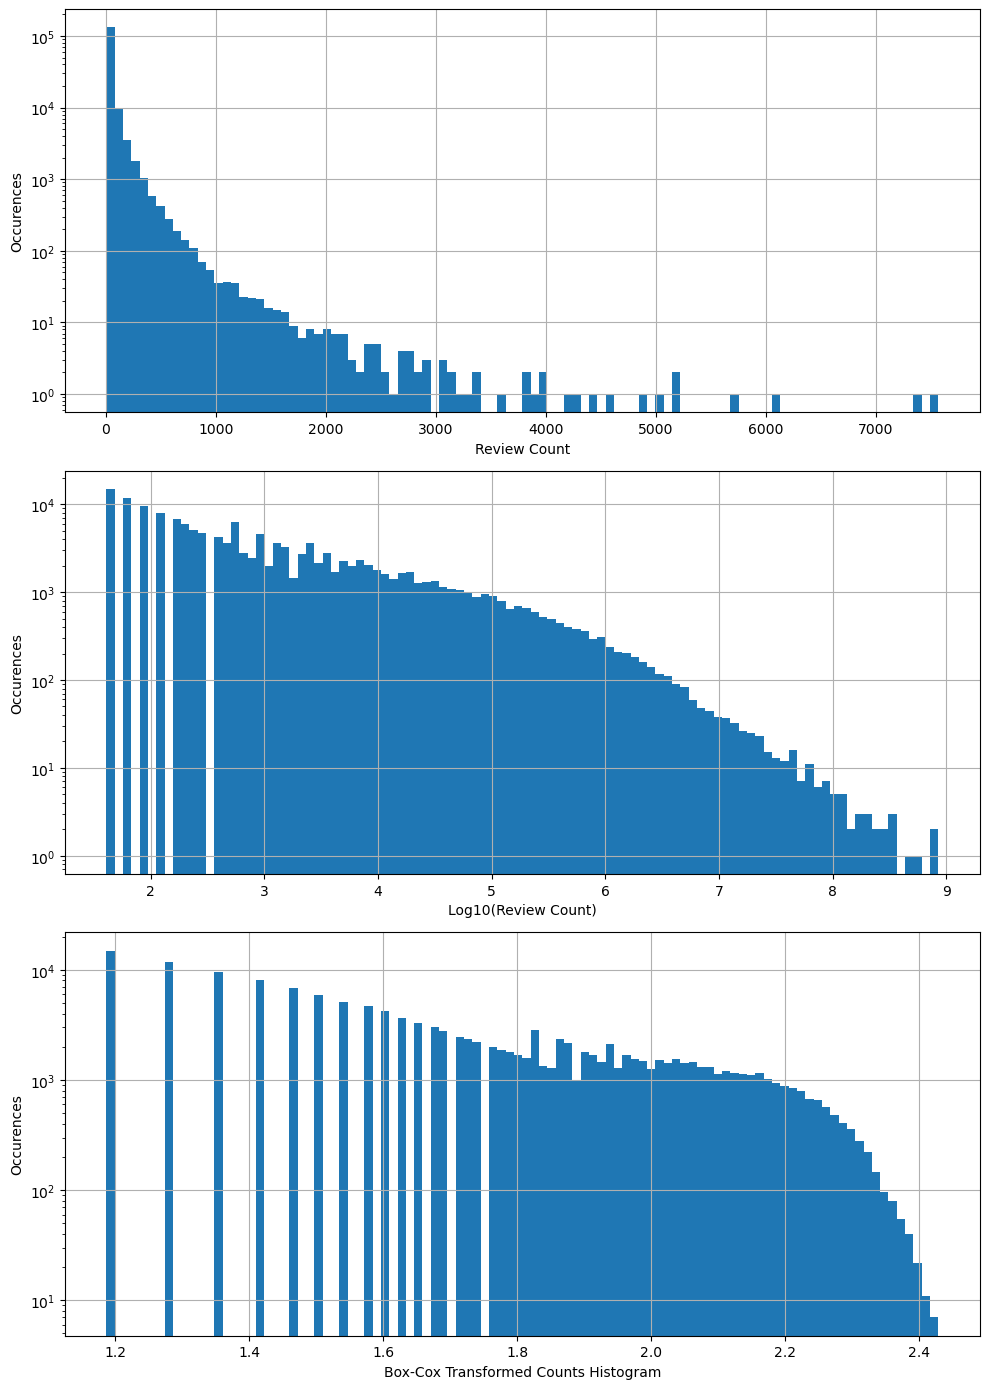

In [268]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10,14))

# PLot the original review count histogram
ax1 = biz_df['review_count'].hist(ax=ax1, bins=100)
ax1.set_yscale('log')
ax1.set_xlabel('Review Count')
ax1.set_ylabel('Occurences')

# PLot the log10 transformation of the review counts
ax2 = biz_df['rc_log'].hist(ax=ax2, bins=100)
ax2.set_yscale('log')
ax2.set_xlabel('Log10(Review Count)')
ax2.set_ylabel('Occurences')

# PLot the box-cox transformation of the review counts
ax3 = biz_df['rc_bc'].hist(ax=ax3, bins=100)
ax3.set_yscale('log')
ax3.set_xlabel('Box-Cox Transformed Counts Histogram')
ax3.set_ylabel('Occurences')

plt.tight_layout()
plt.show()

#### Probability Plots of the Original, Log, and Box-Cox Transformations

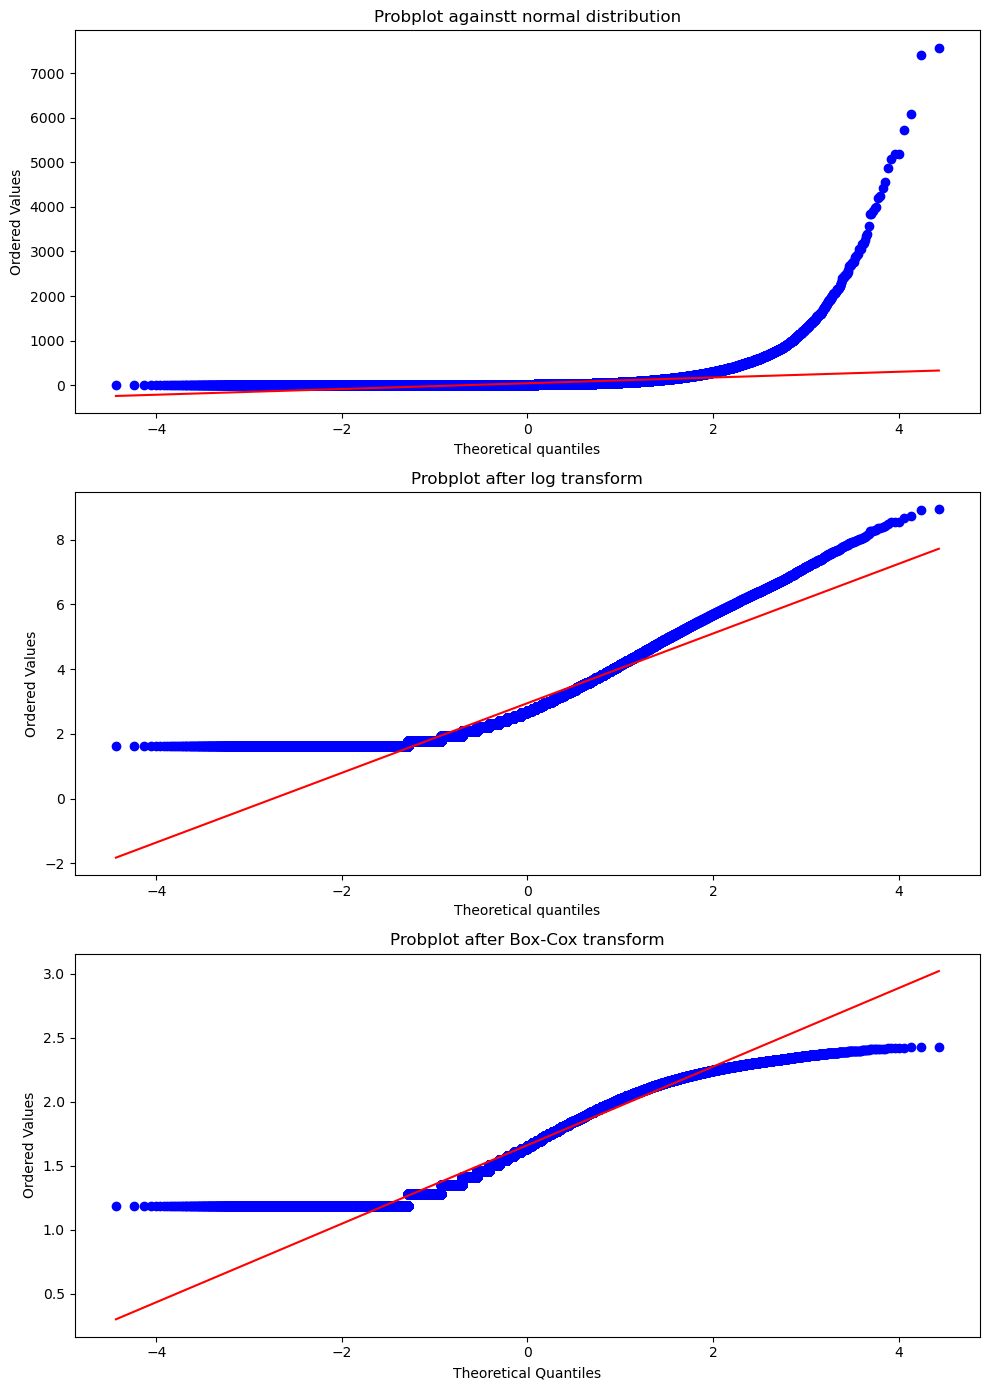

In [339]:
# Plot the probability plots of original, log, and Box-Cox against a normal-distribution
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10,14))

prob1 = probplot(biz_df['review_count'], dist=norm, plot=ax1)
ax1.set_title('Probplot againstt normal distribution')

prob2 = probplot(biz_df['rc_log'], dist=norm, plot=ax2)
ax2.set_title('Probplot after log transform')

prob3 = probplot(biz_df['rc_bc'], dist=norm, plot=ax3)
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_title('Probplot after Box-Cox transform')

plt.tight_layout()
plt.show()

#### L2 Normalization

In [285]:
# Convert n_tokens_content to an array
df['n_tokens_content'].to_numpy()

array([219., 255., 211., ..., 442., 682., 157.])

In [296]:
#Min-max scaling
mms = MinMaxScaler().fit_transform(df[['n_tokens_content']])
df['minmax'] = mms
df.head(3)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_n_tokens_content,minmax
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593,2.342423,0.025844
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711,2.408240,0.030092
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500,2.326336,0.024900


In [297]:
# Use Standard Scaler
ss = StandardScaler().fit_transform(df[['n_tokens_content']])
df['standardized'] = ss
df.head(3)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_n_tokens_content,minmax,standardized
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593,2.342423,0.025844,-0.695210
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711,2.408240,0.030092,-0.618794
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500,2.326336,0.024900,-0.712192


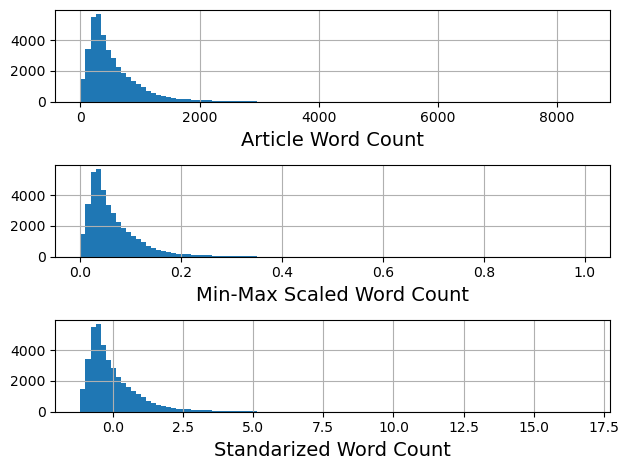

In [340]:
# Plot the original word coutns against the 2 scaled versions (MinMaxScaler and StandardScaler
# The distributions should still look the same
fig, (ax1, ax2, ax3) = plt.subplots(3,1)

df['n_tokens_content'].hist(ax=ax1, bins=100)
ax1.set_xlabel('Article Word Count', fontsize=14)

df['minmax'].hist(ax=ax2, bins=100)
ax2.set_xlabel('Min-Max Scaled Word Count', fontsize=14)

df['standardized'].hist(ax=ax3, bins=100)
ax3.set_xlabel('Standarized Word Count', fontsize=14)

plt.tight_layout()
plt.show()

### Interaction Features

In [341]:
# Display list of columns
df.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [325]:
# Dropped the bad l2_normalized column
#df = df.drop(['l2_normalized'], axis=1)

In [328]:
# Create of features to transform
features = ['n_tokens_title', 'n_tokens_content',
            'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
            'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
            'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
            'data_channel_is_entertainment', 'data_channel_is_bus',
            'data_channel_is_socmed', 'data_channel_is_tech',
            'data_channel_is_world']

In [342]:
# Create the X and y model arrays
X = df[features]
y = df['shares']

In [343]:
# Create the polynomial transformations of the features
X2 = PolynomialFeatures(include_bias = False).fit_transform(X)
X2.shape

(39644, 170)

In [344]:
# Split the X, X2, and y arrays into training and test
X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(X, X2, y, 
                                                                         test_size=0.3,
                                                                         random_state=123)

In [345]:
(m1, r1) = evaluate_feature(X1_train, X1_test, y_train, y_test)
print("R-squared score with singleton features: %0.5f" % r1)

R-squared score with singleton features: 0.00924


In [346]:
(m2, r2) = evaluate_feature(X2_train, X2_test, y_train, y_test)
print("R-squared score with pairwise features: %0.10f" % r2)

R-squared score with pairwise features: 0.0111475204
